In [1]:
import plotly
from plotly.graph_objs import Scatter, Layout
import numpy as np
import os
import pandas as pd
import plotly.graph_objects as go
from plotly.offline import plot
from plotly.subplots import make_subplots

%matplotlib inline

In [2]:
gbd_total = pd.read_csv('gbd_burden_age_standardized.csv')
gbd_total = gbd_total[['measure_id','measure_name','location_id','location_name','cause_id','cause_name','year','val']]

gbd_total

,measure_id,measure_name,location_id,location_name,cause_id,cause_name,year,val
0,1,Deaths,182,Malawi,502,Lower extremity peripheral arterial disease,2019,1.509563
1,1,Deaths,183,Mauritius,493,Ischemic heart disease,2019,100.411514
2,1,Deaths,183,Mauritius,495,Ischemic stroke,2019,35.543028
3,1,Deaths,183,Mauritius,502,Lower extremity peripheral arterial disease,2019,0.638468
4,1,Deaths,201,Burkina Faso,502,Lower extremity peripheral arterial disease,2019,1.498233
...,...,...,...,...,...,...,...,...
4891,6,Incidence,204,Chad,495,Ischemic stroke,2023,119.960187
4892,6,Incidence,218,Togo,495,Ischemic stroke,2023,126.617816
4893,6,Incidence,164,Nepal,493,Ischemic heart disease,2023,162.321205
4894,6,Incidence,204,Chad,502,Lower extremity peripheral arterial disease,2023,103.061382


In [3]:
countries_info = pd.read_csv('../../data/countrycode.csv', encoding='utf-8-sig')
countries_info = countries_info[['Country Code', 'Region', 'Income group', 'WBCountry', 'country']]
iso3 = countries_info[["Country Code", "country"]]
codemap = countries_info.dropna()

countries_info

,Country Code,Region,Income group,WBCountry,country
0,ABW,Latin America and Caribbean,High income,Aruba,NaN
1,AFG,South Asia,Low income,Afghanistan,Afghanistan
2,AGO,Sub-Saharan Africa,Lower middle income,Angola,Angola
3,AIA,NaN,NaN,NaN,NaN
4,ALB,Europe and Central Asia,Upper middle income,Albania,Albania
...,...,...,...,...,...
236,XKX,Europe and Central Asia,Upper middle income,Kosovo,NaN
237,YEM,Middle East and North Africa,Low income,"Yemen, Rep.",Yemen
238,ZAF,Sub-Saharan Africa,Upper middle income,South Africa,South Africa
239,ZMB,Sub-Saharan Africa,Lower middle income,Zambia,Zambia


In [4]:
gbd = gbd_total.merge(iso3, left_on='location_name', right_on='country',how='inner').drop_duplicates()

gbd_2023 = gbd[gbd['year'] == 2023].reset_index(drop=True)
gbd_2019 = gbd[gbd['year'] == 2019].reset_index(drop=True)

gbd_ihd_2023 = gbd_2023[gbd_2023['cause_id'] == 493]
gbd_is_2023 = gbd_2023[gbd_2023['cause_id'] == 495]
gbd_pad_2023 = gbd_2023[gbd_2023['cause_id'] == 502]

gbd_ihd_2019 = gbd_2019[gbd_2019['cause_id'] == 493]
gbd_is_2019 = gbd_2019[gbd_2019['cause_id'] == 495]
gbd_pad_2019 = gbd_2019[gbd_2019['cause_id'] == 502]

gbd_ihd_2023

,measure_id,measure_name,location_id,location_name,cause_id,cause_name,year,val,Country Code,country
0,1,Deaths,6,China,493,Ischemic heart disease,2023,92.684870,CHN,China
3,1,Deaths,7,Democratic People's Republic of Korea,493,Ischemic heart disease,2023,147.935698,PRK,Democratic People's Republic of Korea
6,1,Deaths,121,Bolivia (Plurinational State of),493,Ischemic heart disease,2023,73.027371,BOL,Bolivia (Plurinational State of)
9,1,Deaths,122,Ecuador,493,Ischemic heart disease,2023,84.430240,ECU,Ecuador
14,1,Deaths,105,Antigua and Barbuda,493,Ischemic heart disease,2023,50.353341,ATG,Antigua and Barbuda
...,...,...,...,...,...,...,...,...,...,...
2429,6,Incidence,153,Syrian Arab Republic,493,Ischemic heart disease,2023,412.702705,SYR,Syrian Arab Republic
2433,6,Incidence,203,Cabo Verde,493,Ischemic heart disease,2023,98.115427,CPV,Cabo Verde
2437,6,Incidence,217,Sierra Leone,493,Ischemic heart disease,2023,79.935585,SLE,Sierra Leone
2440,6,Incidence,151,Qatar,493,Ischemic heart disease,2023,228.442661,QAT,Qatar


In [5]:
gbd_ihd_2023[gbd_ihd_2023['location_name']=='United States of America']

,measure_id,measure_name,location_id,location_name,cause_id,cause_name,year,val,Country Code,country
386,1,Deaths,102,United States of America,493,Ischemic heart disease,2023,75.371461,USA,United States of America
1116,2,DALYs (Disability-Adjusted Life Years),102,United States of America,493,Ischemic heart disease,2023,1579.854472,USA,United States of America
1384,5,Prevalence,102,United States of America,493,Ischemic heart disease,2023,3053.899261,USA,United States of America
2211,6,Incidence,102,United States of America,493,Ischemic heart disease,2023,194.368330,USA,United States of America


In [46]:
gbd_ihd_2023_m = gbd_ihd_2023[gbd_ihd_2023['measure_id'] == 1]
gbd_ihd_2023_d = gbd_ihd_2023[gbd_ihd_2023['measure_id'] == 2]
gbd_ihd_2023_p = gbd_ihd_2023[gbd_ihd_2023['measure_id'] == 5]
gbd_ihd_2023_i = gbd_ihd_2023[gbd_ihd_2023['measure_id'] == 6]

gbd_ihd_2019_m = gbd_ihd_2019[gbd_ihd_2019['measure_id'] == 1]
gbd_ihd_2019_d = gbd_ihd_2019[gbd_ihd_2019['measure_id'] == 2]
gbd_ihd_2019_p = gbd_ihd_2019[gbd_ihd_2019['measure_id'] == 5]
gbd_ihd_2019_i = gbd_ihd_2019[gbd_ihd_2019['measure_id'] == 6]

gbd_is_2023_m = gbd_is_2023[gbd_is_2023['measure_id'] == 1]
gbd_is_2023_d = gbd_is_2023[gbd_is_2023['measure_id'] == 2]
gbd_is_2023_p = gbd_is_2023[gbd_is_2023['measure_id'] == 5]
gbd_is_2023_i = gbd_is_2023[gbd_is_2023['measure_id'] == 6]

gbd_is_2019_m = gbd_is_2019[gbd_is_2019['measure_id'] == 1]
gbd_is_2019_d = gbd_is_2019[gbd_is_2019['measure_id'] == 2]
gbd_is_2019_p = gbd_is_2019[gbd_is_2019['measure_id'] == 5]
gbd_is_2019_i = gbd_is_2019[gbd_is_2019['measure_id'] == 6]

gbd_pad_2023_m = gbd_pad_2023[gbd_pad_2023['measure_id'] == 1]
gbd_pad_2023_d = gbd_pad_2023[gbd_pad_2023['measure_id'] == 2]
gbd_pad_2023_p = gbd_pad_2023[gbd_pad_2023['measure_id'] == 5]
gbd_pad_2023_i = gbd_pad_2023[gbd_pad_2023['measure_id'] == 6]

gbd_pad_2019_m = gbd_pad_2019[gbd_pad_2019['measure_id'] == 1]
gbd_pad_2019_d = gbd_pad_2019[gbd_pad_2019['measure_id'] == 2]
gbd_pad_2019_p = gbd_pad_2019[gbd_pad_2019['measure_id'] == 5]
gbd_pad_2019_i = gbd_pad_2019[gbd_pad_2019['measure_id'] == 6]

gbd = dict(
   ihd_2023 = [gbd_ihd_2023_m, gbd_ihd_2023_d, gbd_ihd_2023_p, gbd_ihd_2023_i],
   is_2023 = [gbd_is_2023_m, gbd_is_2023_d, gbd_is_2023_p, gbd_is_2023_i],
   pad_2023 = [gbd_pad_2023_m, gbd_pad_2023_d, gbd_pad_2023_p, gbd_pad_2023_i],
   ihd_2019 = [gbd_ihd_2019_m, gbd_ihd_2019_d, gbd_ihd_2019_p, gbd_ihd_2019_i],
   is_2019 = [gbd_is_2019_m, gbd_is_2019_d, gbd_is_2019_p, gbd_is_2019_i],
   pad_2019 = [gbd_pad_2019_m, gbd_pad_2019_d, gbd_pad_2019_p, gbd_pad_2019_i]
)

gbd.keys()

dict_keys(['ihd_2023', 'is_2023', 'pad_2023', 'ihd_2019', 'is_2019', 'pad_2019'])

## 2023 Burden Plots

In [44]:
from matplotlib.colors import LinearSegmentedColormap, to_rgb, to_hex

def lighten_color(color, amount=0.5):
    r, g, b = to_rgb(color)
    r += (1 - r) * amount
    g += (1 - g) * amount
    b += (1 - b) * amount
    return to_hex((r, g, b))

def darken_color(color, amount=0.5):
    r, g, b = to_rgb(color)
    r *= (1 - amount)
    g *= (1 - amount)
    b *= (1 - amount)
    return to_hex((r, g, b))

def mpl_to_plotly_colorscale(cmap, n=256):
    return [[i/(n-1), to_hex(cmap(i/(n-1)), keep_alpha=False)] for i in range(n)]

r = "#e35e47"
y = "#f1b364"
g = "#9da27a"
b = "#567a80"

lr = lighten_color(r, amount=0.75)
dr = darken_color(r, amount=0.5)
ar = [lr, r, dr]

ly = lighten_color(y, amount=0.75)
dy = darken_color(y, amount=0.5)
ay = [ly, y, dy]

lg = lighten_color(g, amount=0.75)
dg = darken_color(g, amount=0.5)
ag = [lg, g, dg]

lb = lighten_color(b, amount=0.75)
db = darken_color(b, amount=0.5)
ab = [lb, b, db]

rmap = LinearSegmentedColormap.from_list("red", ar, N=256)
ymap = LinearSegmentedColormap.from_list("yellow", ay, N=256)
gmap = LinearSegmentedColormap.from_list("green", ag, N=256)
bmap = LinearSegmentedColormap.from_list("blue", ab, N=256)

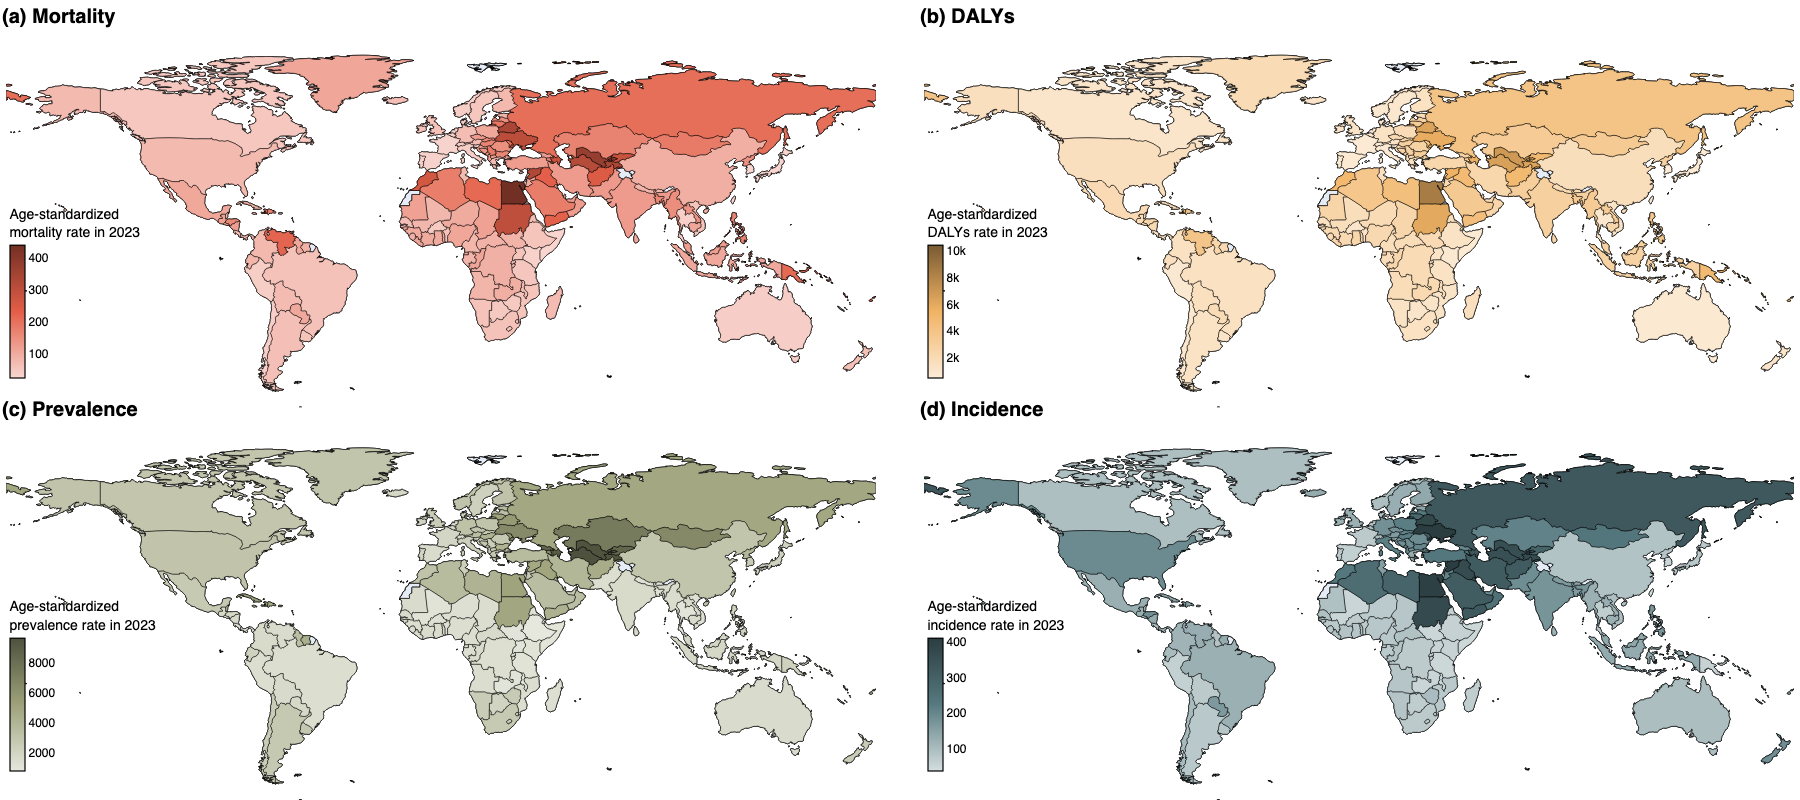

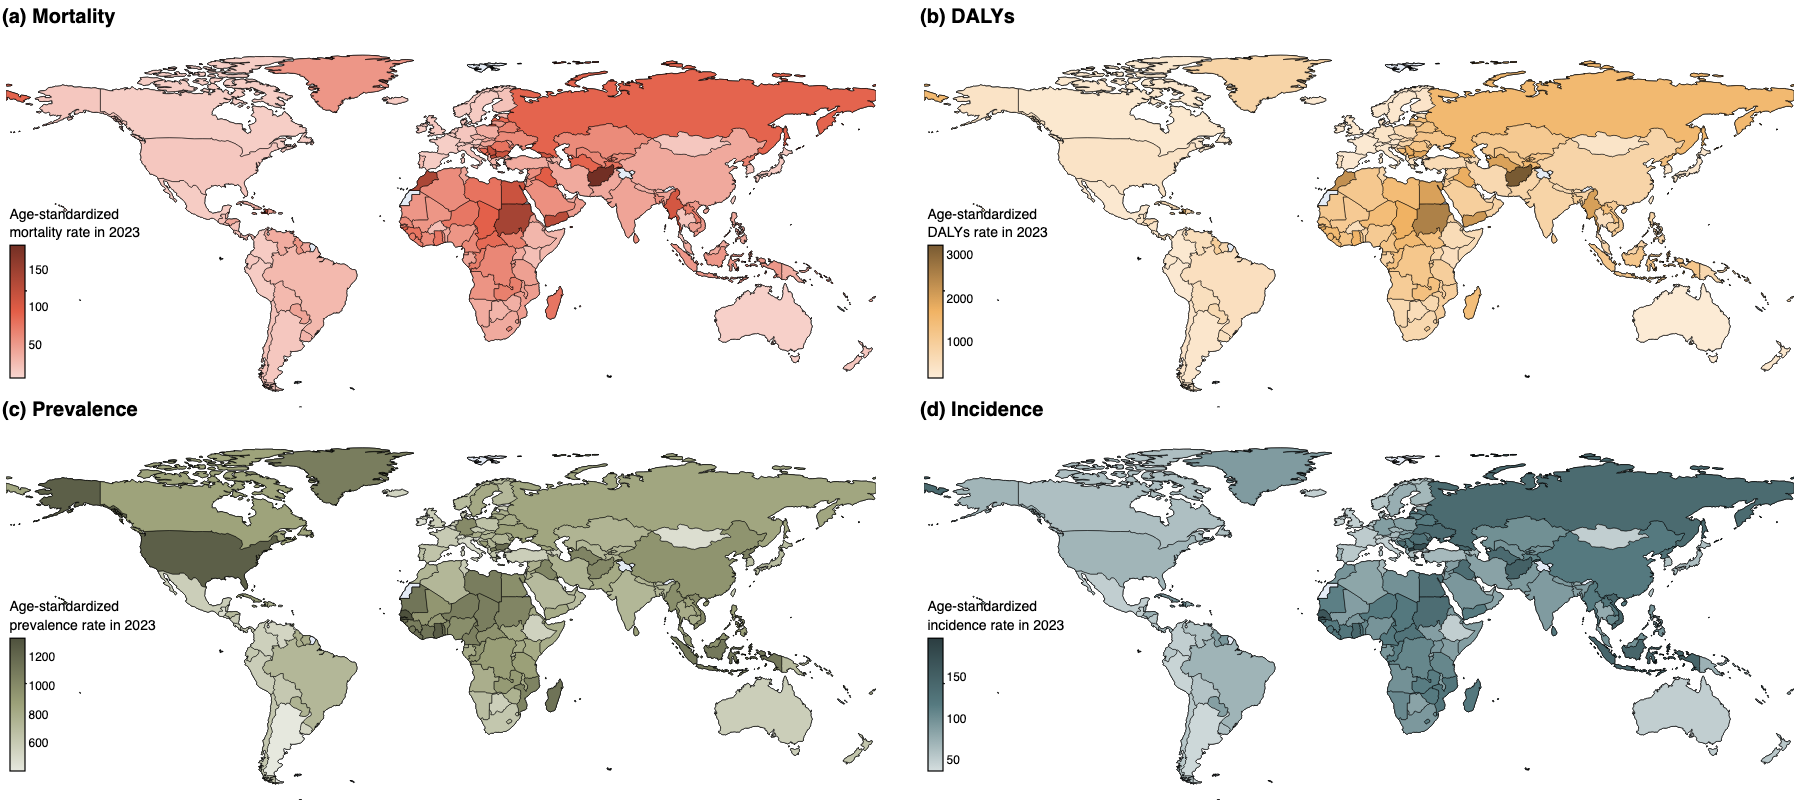

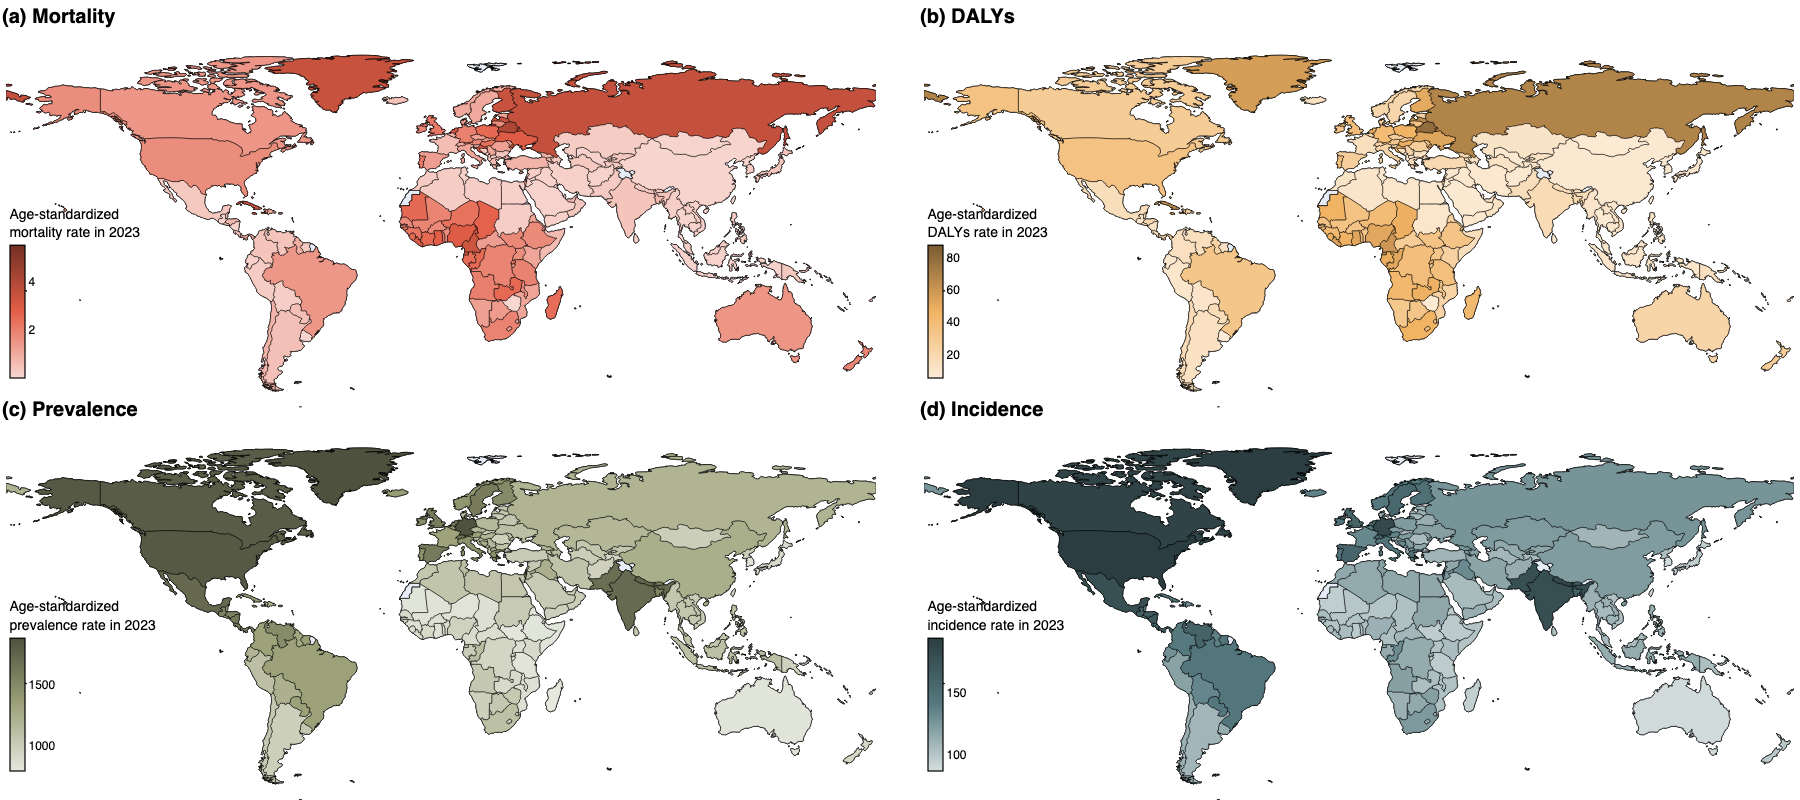

In [49]:
def plot_gbd_burden(disease, year):
    
    d_y = gbd[f"{disease}_{year}"]  
    datasets = [
        (d_y[0], 'Mortality'),
        (d_y[1], 'DALYs'),
        (d_y[2], 'Prevalence'),
        (d_y[3], 'Incidence'),
    ]

    estimate_style = {
        'mortality':  dict(colorscale=mpl_to_plotly_colorscale(rmap)),
        'DALYs':      dict(colorscale=mpl_to_plotly_colorscale(ymap)),
        'prevalence': dict(colorscale=mpl_to_plotly_colorscale(gmap)),
        'incidence':  dict(colorscale=mpl_to_plotly_colorscale(bmap)),
    }

    fig = make_subplots(
        rows=2, cols=2,
        specs=[[{"type": "choropleth"}, {"type": "choropleth"}],
            [{"type": "choropleth"}, {"type": "choropleth"}]],
        subplot_titles=[f"({chr(97+i)}) {t}" for i, (_, t) in enumerate(datasets)],
        vertical_spacing=0.02,
        horizontal_spacing=0.02,
    )

    colorbar_positions = []

    for idx in range(len(datasets)):
        geo_key = "geo" if idx == 0 else f"geo{idx+1}"
        dom = fig.layout[geo_key].domain
        x0, x1 = dom.x
        y0, y1 = dom.y

        x_rel = 0.00 
        y_rel = 0.306

        colorbar_positions.append(dict(
            x=x0 + x_rel * (x1 - x0),
            y=y0 + y_rel * (y1 - y0),
            len=0.51 * (y1 - y0),
        ))

    for i, ann in enumerate(fig.layout.annotations[:len(datasets)]):
        geo_key = "geo" if i == 0 else f"geo{i+1}"
        x0 = fig.layout[geo_key].domain.x[0]  # 각 subplot의 왼쪽 경계
        ann.update(
            x=x0,
            xanchor="left",
            align="left",
            font=dict(family="Helvetica", size=20),
            text=f"<b>{ann.text}</b>"
        )

    for idx, (data, title) in enumerate(datasets):
        row, col = divmod(idx, 2)
        row += 1
        col += 1
        if title != 'DALYs':
            title = title.lower()
        bar_pos = colorbar_positions[idx]
        fig.add_trace(
            go.Choropleth(
                **estimate_style[title],
                colorbar_title=f'Age-standardized<br>{title} rate in {year}',
                locations=data['Country Code'],
                z=data['val'],
                autocolorscale=False,
                marker=dict(line=dict(color='rgb(0,0,0)', width=0.5)),
                colorbar=dict(
                    x=bar_pos["x"],
                    y=bar_pos["y"],
                    len=bar_pos["len"],
                    thickness=15,
                    outlinewidth=1.2,
                    outlinecolor='rgb(0,0,0)'
                ),
            ),
            row=row, col=col
        )

    geo_common = dict(
        showframe=False,
        showcoastlines=True,
        coastlinecolor="rgb(0,0,0)",
        coastlinewidth=0.7,
        showcountries=True,
        countrycolor="rgb(0, 0, 0)",
        countrywidth=0.7,
        showlakes=False,
        projection_type='equirectangular',
        lataxis_range=[-58, 90],
    )
    fig.update_geos(**geo_common)

    fig.update_layout(
        font=dict(family="Helvetica", size=12, color='black'),
        margin={'l': 0, 'r': 0, 't': 30, 'b': 0},
        height=800, width=1800,
    )

    fig.show(renderer='png')

    fig.write_image(f"../../figures/figure_S1_{disease.upper()}_{year}.pdf")
    fig.write_image(f"../../figures/figure_S1_{disease.upper()}_{year}.svg")
    fig.write_image(f"../../figures/figure_S1_{disease.upper()}_{year}.png", scale=3)

plot_gbd_burden('ihd', 2023)
plot_gbd_burden('is', 2023)
plot_gbd_burden('pad', 2023)
# plot_gbd_burden('ihd', 2019)
# plot_gbd_burden('is', 2019)
# plot_gbd_burden('pad', 2019)